In [1]:
import pandas as pd

# ============================================================
# LOAD PREPARED DATA
# ============================================================

ARTIFACT_DIR = "../artifacts/feature_engineering"

# ------------------------------------------------------------
# Classification
# ------------------------------------------------------------

X_train_scaled = pd.read_csv(f"{ARTIFACT_DIR}/train_features.csv")
X_validation_scaled = pd.read_csv(f"{ARTIFACT_DIR}/validation_features.csv")
X_test_scaled = pd.read_csv(f"{ARTIFACT_DIR}/test_features.csv")

y_train = pd.read_csv(f"{ARTIFACT_DIR}/y_train.csv").squeeze()
y_validation = pd.read_csv(f"{ARTIFACT_DIR}/y_validation.csv").squeeze()
y_test = pd.read_csv(f"{ARTIFACT_DIR}/y_test.csv").squeeze()

# ------------------------------------------------------------
# Regression
# ------------------------------------------------------------

X_train_reg_scaled = X_train_scaled
X_validation_reg_scaled = X_validation_scaled
X_test_reg_scaled = X_test_scaled

y_train_reg = pd.read_csv(f"{ARTIFACT_DIR}/y_train_reg.csv").squeeze()
y_validation_reg = pd.read_csv(f"{ARTIFACT_DIR}/y_validation_reg.csv").squeeze()
y_test_reg = pd.read_csv(f"{ARTIFACT_DIR}/y_test_reg.csv").squeeze()

print("Data loaded successfully.")

Data loaded successfully.


In [2]:
X_train_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 67527 entries, 0 to 67526
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_lat                         67527 non-null  float64
 1   customer_lng                         67527 non-null  float64
 2   item_count                           67527 non-null  float64
 3   unique_products                      67527 non-null  float64
 4   seller_count                         67527 non-null  float64
 5   total_price                          67527 non-null  float64
 6   min_freight                          67527 non-null  float64
 7   unique_seller_states                 67527 non-null  float64
 8   sellers_same_customer_state          67527 non-null  float64
 9   unique_category_count                67527 non-null  float64
 10  min_weight_g                         67527 non-null  float64
 11  min_volume_cm3                       67

# Delay (Binary Classification)

## Train 1

In [2]:
# ============================================================
# BINARY CLASSIFICATION — 5 MODELS
# Imbalanced Data — No SMOTE / No Resampling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier


# ============================================================
# 1. MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}


# ============================================================
# 2. TRAIN + VALIDATION + TEST
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    # Train
    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_pred = model.predict(X_validation_scaled)
    val_prob = model.predict_proba(X_validation_scaled)[:, 1]

    val_accuracy = accuracy_score(y_validation, val_pred)
    val_f1 = f1_score(y_validation, val_pred, zero_division=0)
    val_precision = precision_score(
        y_validation,
        val_pred,
        zero_division=0
    )
    val_recall = recall_score(
        y_validation,
        val_pred,
        zero_division=0
    )
    val_roc_auc = roc_auc_score(y_validation, val_prob)

    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_pred = model.predict(X_test_scaled)
    test_prob = model.predict_proba(X_test_scaled)[:, 1]

    test_accuracy = accuracy_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)
    test_precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )
    test_recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )
    test_roc_auc = roc_auc_score(y_test, test_prob)

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results.append({
        "Model": name,

        "Validation Accuracy": val_accuracy,
        "Validation F1": val_f1,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation ROC-AUC": val_roc_auc,

        "Test Accuracy": test_accuracy,
        "Test F1": test_f1,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test ROC-AUC": test_roc_auc
    })

    print(
        f"Validation | "
        f"Accuracy: {val_accuracy:.4f} | "
        f"F1: {val_f1:.4f} | "
        f"Precision: {val_precision:.4f} | "
        f"Recall: {val_recall:.4f} | "
        f"ROC-AUC: {val_roc_auc:.4f}"
    )

    print(
        f"Test       | "
        f"Accuracy: {test_accuracy:.4f} | "
        f"F1: {test_f1:.4f} | "
        f"Precision: {test_precision:.4f} | "
        f"Recall: {test_recall:.4f} | "
        f"ROC-AUC: {test_roc_auc:.4f}"
    )


# ============================================================
# 3. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

# Sort by Validation F1
results_df = results_df.sort_values(
    by="Validation F1",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)

display(
    results_df.style.format({
        col: "{:.4f}"
        for col in results_df.columns
        if col != "Model"
    })
)

Training: Logistic Regression
Validation | Accuracy: 0.4887 | F1: 0.1214 | Precision: 0.0668 | Recall: 0.6611 | ROC-AUC: 0.6073
Test       | Accuracy: 0.4416 | F1: 0.1286 | Precision: 0.0717 | Recall: 0.6228 | ROC-AUC: 0.5418
Training: Random Forest
Validation | Accuracy: 0.9383 | F1: 0.0708 | Precision: 0.1809 | Recall: 0.0440 | ROC-AUC: 0.6419
Test       | Accuracy: 0.9238 | F1: 0.0178 | Precision: 0.0606 | Recall: 0.0104 | ROC-AUC: 0.5390
Training: HistGradientBoosting
Validation | Accuracy: 0.9377 | F1: 0.0505 | Precision: 0.1356 | Recall: 0.0310 | ROC-AUC: 0.6317
Test       | Accuracy: 0.9250 | F1: 0.0216 | Precision: 0.0784 | Recall: 0.0125 | ROC-AUC: 0.5274
Training: XGBoost
Validation | Accuracy: 0.9389 | F1: 0.0576 | Precision: 0.1636 | Recall: 0.0349 | ROC-AUC: 0.6392
Test       | Accuracy: 0.9261 | F1: 0.0184 | Precision: 0.0758 | Recall: 0.0104 | ROC-AUC: 0.5202
Training: LightGBM
Validation | Accuracy: 0.8193 | F1: 0.1589 | Precision: 0.1057 | Recall: 0.3195 | ROC-AUC: 0.6

,Model,Validation Accuracy,Validation F1,Validation Precision,Validation Recall,Validation ROC-AUC,Test Accuracy,Test F1,Test Precision,Test Recall,Test ROC-AUC
0,LightGBM,0.8193,0.1589,0.1057,0.3195,0.6410,0.8194,0.1121,0.0830,0.1724,0.5346
1,Logistic Regression,0.4887,0.1214,0.0668,0.6611,0.6073,0.4416,0.1286,0.0717,0.6228,0.5418
2,Random Forest,0.9383,0.0708,0.1809,0.0440,0.6419,0.9238,0.0178,0.0606,0.0104,0.5390
3,XGBoost,0.9389,0.0576,0.1636,0.0349,0.6392,0.9261,0.0184,0.0758,0.0104,0.5202
4,HistGradientBoosting,0.9377,0.0505,0.1356,0.0310,0.6317,0.9250,0.0216,0.0784,0.0125,0.5274


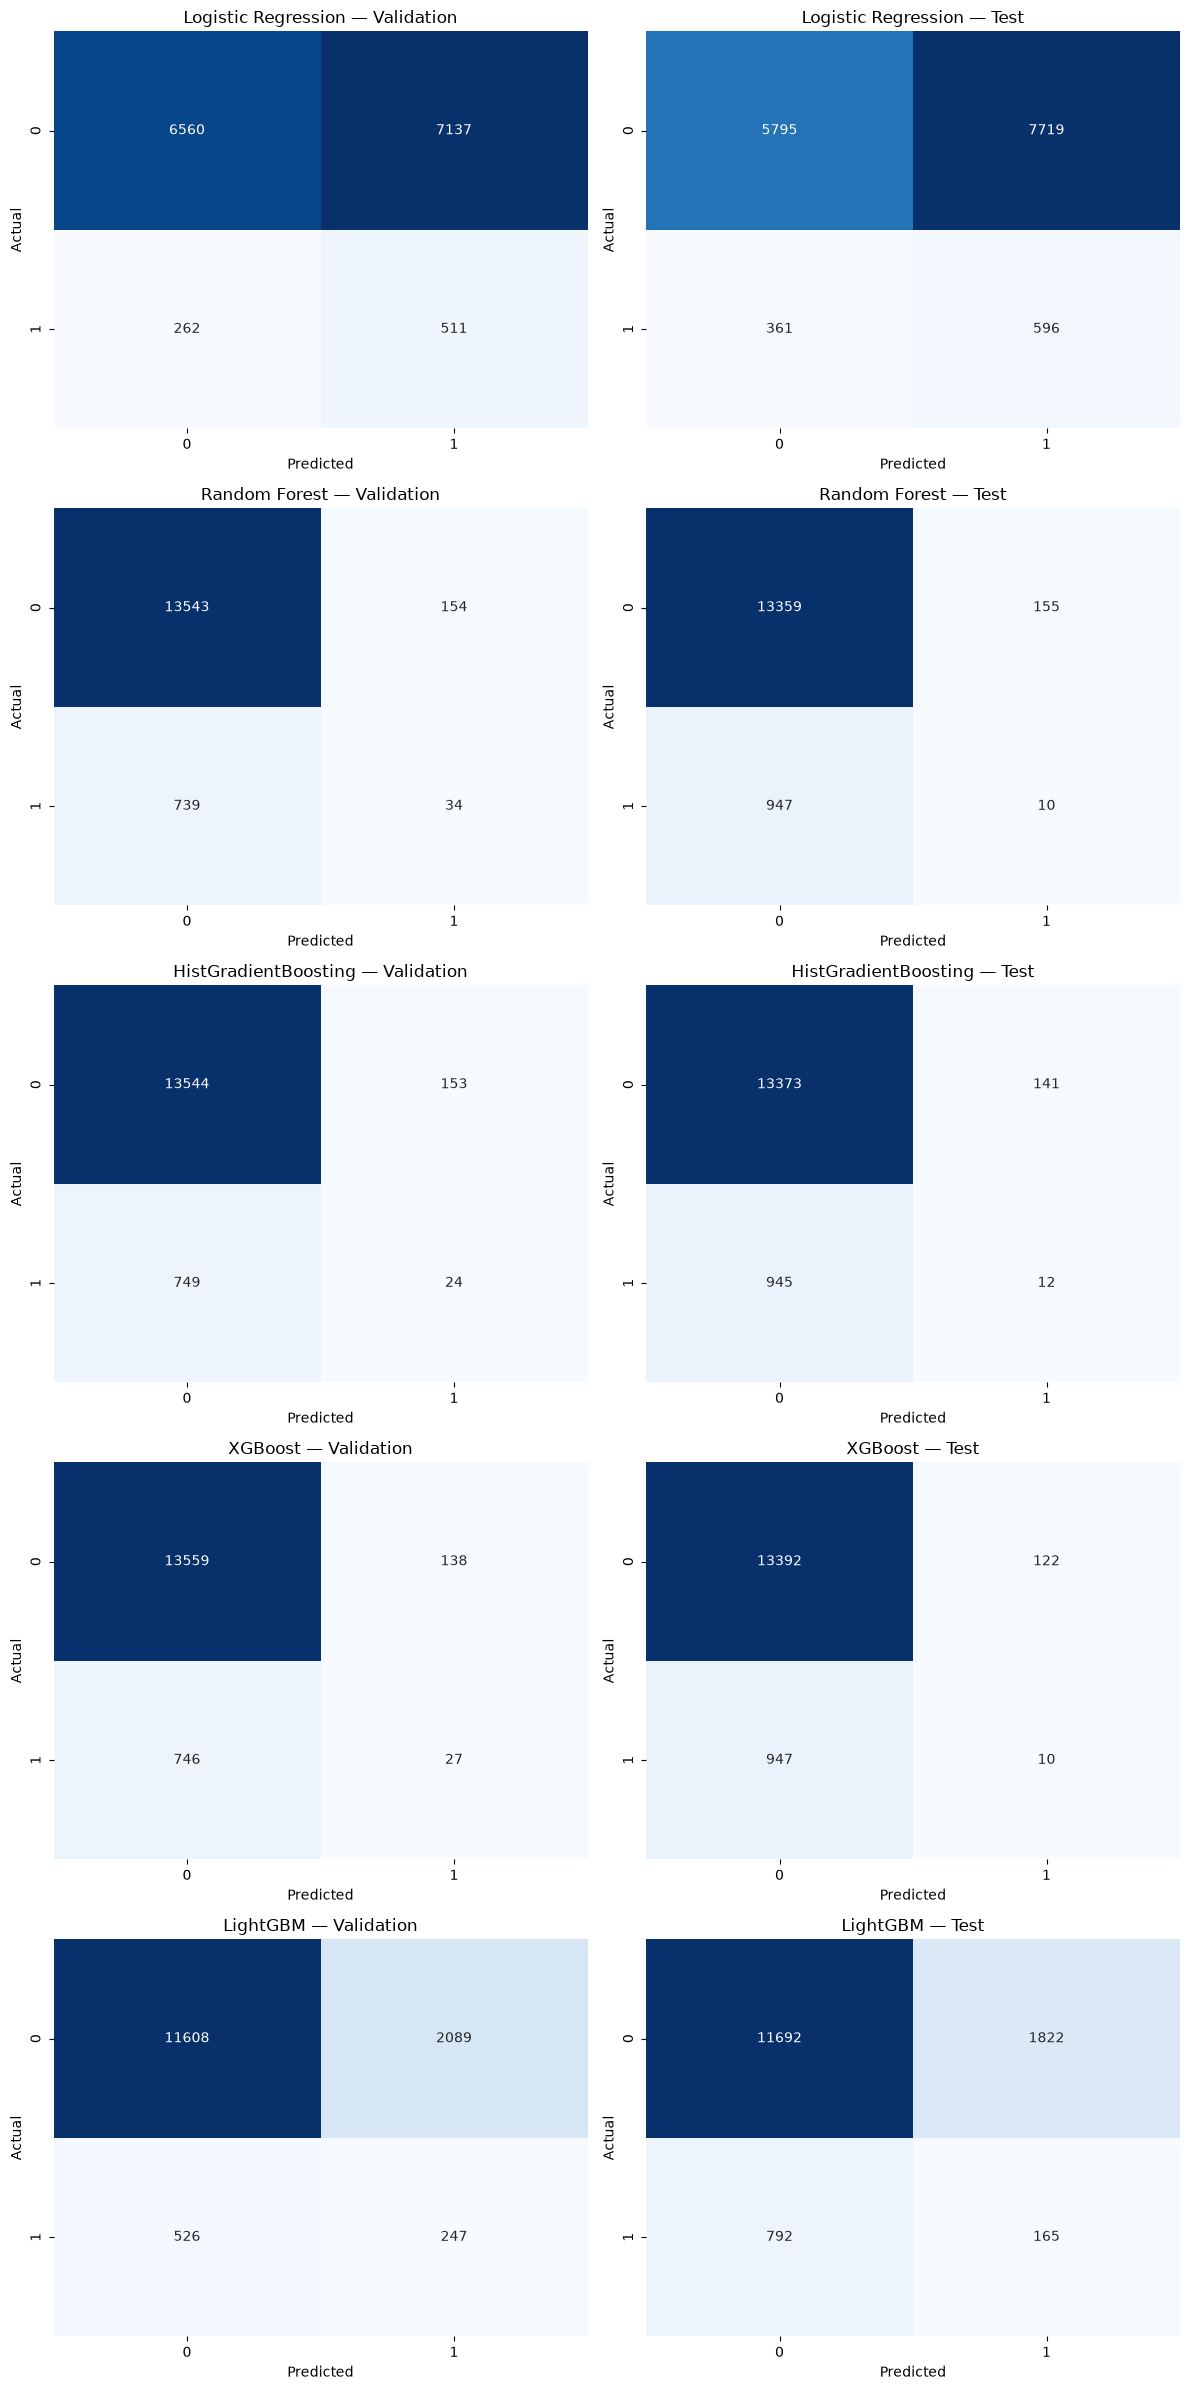

In [3]:
# ============================================================
# CONFUSION MATRICES — VALIDATION + TEST
# ============================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(12, 24)
)

for row, (name, model) in enumerate(trained_models.items()):

    # Predictions
    val_pred = model.predict(X_validation_scaled)
    test_pred = model.predict(X_test_scaled)

    # Confusion matrices
    cm_val = confusion_matrix(y_validation, val_pred)
    cm_test = confusion_matrix(y_test, test_pred)

    # Validation
    sns.heatmap(
        cm_val,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[row, 0]
    )

    axes[row, 0].set_title(f"{name} — Validation")
    axes[row, 0].set_xlabel("Predicted")
    axes[row, 0].set_ylabel("Actual")

    # Test
    sns.heatmap(
        cm_test,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[row, 1]
    )

    axes[row, 1].set_title(f"{name} — Test")
    axes[row, 1].set_xlabel("Predicted")
    axes[row, 1].set_ylabel("Actual")


plt.tight_layout()
plt.show()

## Train 2 (SMOTE)

In [3]:
# ============================================================
# BINARY CLASSIFICATION — 5 MODELS
# SMOTE — ADD 3,000 DELAYED SAMPLES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ============================================================
# 1. SMOTE — TRAIN ONLY
# ============================================================

print("Original Train distribution:")
print(y_train.value_counts().sort_index())

delayed_count = (y_train == 1).sum()

smote = SMOTE(
    sampling_strategy={
        1: delayed_count + 3000
    },
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

print("\nAdded delayed samples:",
      (y_train_smote == 1).sum() - delayed_count)


# ============================================================
# 2. MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}


# ============================================================
# 3. TRAIN + VALIDATION + TEST
# ============================================================

results_smote = []

trained_models_smote = {}

for name, model in models.items():

    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    # Train on SMOTE data
    model.fit(X_train_smote, y_train_smote)

    trained_models_smote[name] = model

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_pred = model.predict(X_validation_scaled)
    val_prob = model.predict_proba(X_validation_scaled)[:, 1]

    val_accuracy = accuracy_score(y_validation, val_pred)
    val_f1 = f1_score(y_validation, val_pred, zero_division=0)
    val_precision = precision_score(
        y_validation,
        val_pred,
        zero_division=0
    )
    val_recall = recall_score(
        y_validation,
        val_pred,
        zero_division=0
    )
    val_roc_auc = roc_auc_score(y_validation, val_prob)

    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_pred = model.predict(X_test_scaled)
    test_prob = model.predict_proba(X_test_scaled)[:, 1]

    test_accuracy = accuracy_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)
    test_precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )
    test_recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )
    test_roc_auc = roc_auc_score(y_test, test_prob)

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results_smote.append({
        "Model": name,

        "Validation Accuracy": val_accuracy,
        "Validation F1": val_f1,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation ROC-AUC": val_roc_auc,

        "Test Accuracy": test_accuracy,
        "Test F1": test_f1,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test ROC-AUC": test_roc_auc
    })

    print(
        f"Validation | "
        f"Accuracy: {val_accuracy:.4f} | "
        f"F1: {val_f1:.4f} | "
        f"Precision: {val_precision:.4f} | "
        f"Recall: {val_recall:.4f} | "
        f"ROC-AUC: {val_roc_auc:.4f}"
    )

    print(
        f"Test       | "
        f"Accuracy: {test_accuracy:.4f} | "
        f"F1: {test_f1:.4f} | "
        f"Precision: {test_precision:.4f} | "
        f"Recall: {test_recall:.4f} | "
        f"ROC-AUC: {test_roc_auc:.4f}"
    )


# ============================================================
# 4. RESULTS TABLE
# ============================================================

results_smote_df = pd.DataFrame(results_smote)

results_smote_df = results_smote_df.sort_values(
    by="Validation F1",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("MODEL COMPARISON — SMOTE (+3,000 DELAYED)")
print("=" * 100)

display(
    results_smote_df.style.format({
        col: "{:.4f}"
        for col in results_smote_df.columns
        if col != "Model"
    })
)

Original Train distribution:
delayed
0    61431
1     6096
Name: count, dtype: int64

After SMOTE:
delayed
0    61431
1     9096
Name: count, dtype: int64

Added delayed samples: 3000
Training: Logistic Regression
Validation | Accuracy: 0.5010 | F1: 0.1227 | Precision: 0.0677 | Recall: 0.6533 | ROC-AUC: 0.6050
Test       | Accuracy: 0.4605 | F1: 0.1305 | Precision: 0.0730 | Recall: 0.6123 | ROC-AUC: 0.5461
Training: Random Forest
Validation | Accuracy: 0.9365 | F1: 0.0819 | Precision: 0.1798 | Recall: 0.0530 | ROC-AUC: 0.6457
Test       | Accuracy: 0.9214 | F1: 0.0139 | Precision: 0.0406 | Recall: 0.0084 | ROC-AUC: 0.5489
Training: HistGradientBoosting
Validation | Accuracy: 0.9355 | F1: 0.0697 | Precision: 0.1515 | Recall: 0.0453 | ROC-AUC: 0.6353
Test       | Accuracy: 0.9212 | F1: 0.0256 | Precision: 0.0704 | Recall: 0.0157 | ROC-AUC: 0.5251
Training: XGBoost
Validation | Accuracy: 0.9378 | F1: 0.0586 | Precision: 0.1530 | Recall: 0.0362 | ROC-AUC: 0.6393
Test       | Accuracy: 0.92

,Model,Validation Accuracy,Validation F1,Validation Precision,Validation Recall,Validation ROC-AUC,Test Accuracy,Test F1,Test Precision,Test Recall,Test ROC-AUC
0,LightGBM,0.8455,0.1492,0.1057,0.2536,0.6365,0.8448,0.1116,0.0898,0.1473,0.5347
1,Logistic Regression,0.5010,0.1227,0.0677,0.6533,0.6050,0.4605,0.1305,0.0730,0.6123,0.5461
2,Random Forest,0.9365,0.0819,0.1798,0.0530,0.6457,0.9214,0.0139,0.0406,0.0084,0.5489
3,HistGradientBoosting,0.9355,0.0697,0.1515,0.0453,0.6353,0.9212,0.0256,0.0704,0.0157,0.5251
4,XGBoost,0.9378,0.0586,0.1530,0.0362,0.6393,0.9252,0.0181,0.0685,0.0104,0.5213


In [4]:
# ============================================================
# MLFLOW — LOG SMOTE CLASSIFICATION EXPERIMENT
# ============================================================

from pathlib import Path
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("Brazilian-E-Commerce-Classification")

MODEL_NAME = "Logistic Regression"
MODEL_PATH = Path("../artifacts/models/classification/logistic_regression_smote.joblib")

model = trained_models_smote[MODEL_NAME]

model_results = results_smote_df[
    results_smote_df["Model"] == MODEL_NAME
].iloc[0]

with mlflow.start_run(run_name="logistic-regression-smote") as run:
    mlflow.log_params({
        "model": MODEL_NAME,
        "smote_added_samples": 3000,
        "class_weight": "balanced",
        "max_iter": 1000,
        "random_state": 42
    })

    mlflow.log_metrics({
        "validation_accuracy": model_results["Validation Accuracy"],
        "validation_f1": model_results["Validation F1"],
        "validation_precision": model_results["Validation Precision"],
        "validation_recall": model_results["Validation Recall"],
        "validation_roc_auc": model_results["Validation ROC-AUC"],
        "test_accuracy": model_results["Test Accuracy"],
        "test_f1": model_results["Test F1"],
        "test_precision": model_results["Test Precision"],
        "test_recall": model_results["Test Recall"],
        "test_roc_auc": model_results["Test ROC-AUC"]
    })

    mlflow.log_artifact(
        str(MODEL_PATH),
        artifact_path="joblib_model"
    )

    mlflow.sklearn.log_model(
        sk_model=model,
        name="logistic_regression_smote"
    )

    print("=" * 70)
    print("MLflow classification run logged successfully.")
    print("=" * 70)
    print("Run ID:", run.info.run_id)
    print("Experiment ID:", run.info.experiment_id)

2026/09/18 15:08:44 INFO mlflow.tracking.fluent: Experiment with name 'Brazilian-E-Commerce-Classification' does not exist. Creating a new experiment.


MLflow classification run logged successfully.
Run ID: 72d1bac104254590add290fe24b0a2be
Experiment ID: 1
🏃 View run logistic-regression-smote at: http://mlflow:5000/#/experiments/1/runs/72d1bac104254590add290fe24b0a2be
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [8]:
# ============================================================
# VERIFY MLFLOW RUN
# ============================================================

import mlflow

mlflow.set_tracking_uri("http://mlflow:5000")

run_id = "72d1bac104254590add290fe24b0a2be"

run = mlflow.get_run(run_id)

print("=" * 70)
print("MLflow Run Verification")
print("=" * 70)

print("Run ID:", run.info.run_id)
print("Experiment ID:", run.info.experiment_id)

print("\nParameters:")
for key, value in run.data.params.items():
    print(f"{key}: {value}")

print("\nMetrics:")
for key, value in run.data.metrics.items():
    print(f"{key}: {value}")

print("\nArtifacts:")
for artifact in mlflow.artifacts.list_artifacts(run_id):
    print(artifact.path)

MLflow Run Verification
Run ID: 72d1bac104254590add290fe24b0a2be
Experiment ID: 1

Parameters:
model: Logistic Regression
smote_added_samples: 3000
class_weight: balanced
max_iter: 1000
random_state: 42

Metrics:
validation_accuracy: 0.5009675190048376
validation_f1: 0.12270683999514033
validation_precision: 0.06771252346473586
validation_recall: 0.6532988357050453
validation_roc_auc: 0.6049995745095218
test_accuracy: 0.46050722133923017
test_f1: 0.130526784719902
test_precision: 0.0730491149339317
test_recall: 0.6123301985370951
test_roc_auc: 0.5461216813122628

Artifacts:


In [9]:
"""
/mlflow/artifacts/1/72d1bac104254590add290fe24b0a2be/artifacts/joblib_model/logistic_regression_smote.joblib
"""

'\n/mlflow/artifacts/1/72d1bac104254590add290fe24b0a2be/artifacts/joblib_model/logistic_regression_smote.joblib\n'

In [11]:
"""
/mlflow/artifacts/1/models/m-4789286861b44ae1be21a2f349af17ce/artifacts/
├── MLmodel
├── model.skops
├── conda.yaml
├── requirements.txt
└── python_env.yaml
"""

'\n/mlflow/artifacts/1/models/m-4789286861b44ae1be21a2f349af17ce/artifacts/\n├── MLmodel\n├── model.skops\n├── conda.yaml\n├── requirements.txt\n└── python_env.yaml\n'

In [7]:
import mlflow

mlflow.set_tracking_uri("http://mlflow:5000")

run_id = "72d1bac104254590add290fe24b0a2be"

run = mlflow.get_run(run_id)

print("=" * 70)
print("MLflow Artifact URI")
print("=" * 70)
print(run.info.artifact_uri)

MLflow Artifact URI
mlflow-artifacts:/1/72d1bac104254590add290fe24b0a2be/artifacts


In [14]:
# ============================================================
# VERIFY REGISTERED MODEL
# ============================================================

import mlflow

mlflow.set_tracking_uri("http://mlflow:5000")

MODEL_URI = "models:/Brazilian-E-Commerce-Classifier/1"

print("=" * 70)
print("Registered Model Verification")
print("=" * 70)

model = mlflow.sklearn.load_model(MODEL_URI)

print("Model URI:", MODEL_URI)
print("Model type:", type(model).__name__)
print("Number of features:", model.n_features_in_)

X_test_sample = X_test_scaled.iloc[[0]]

prediction = model.predict(X_test_sample)[0]
probability = model.predict_proba(X_test_sample)[0, 1]

print("Prediction:", int(prediction))
print("Probability:", float(probability))
print("Model loaded successfully from MLflow Registry.")

Registered Model Verification


Model URI: models:/Brazilian-E-Commerce-Classifier/1
Model type: LogisticRegression
Number of features: 30
Prediction: 1
Probability: 0.6004965668449761
Model loaded successfully from MLflow Registry.


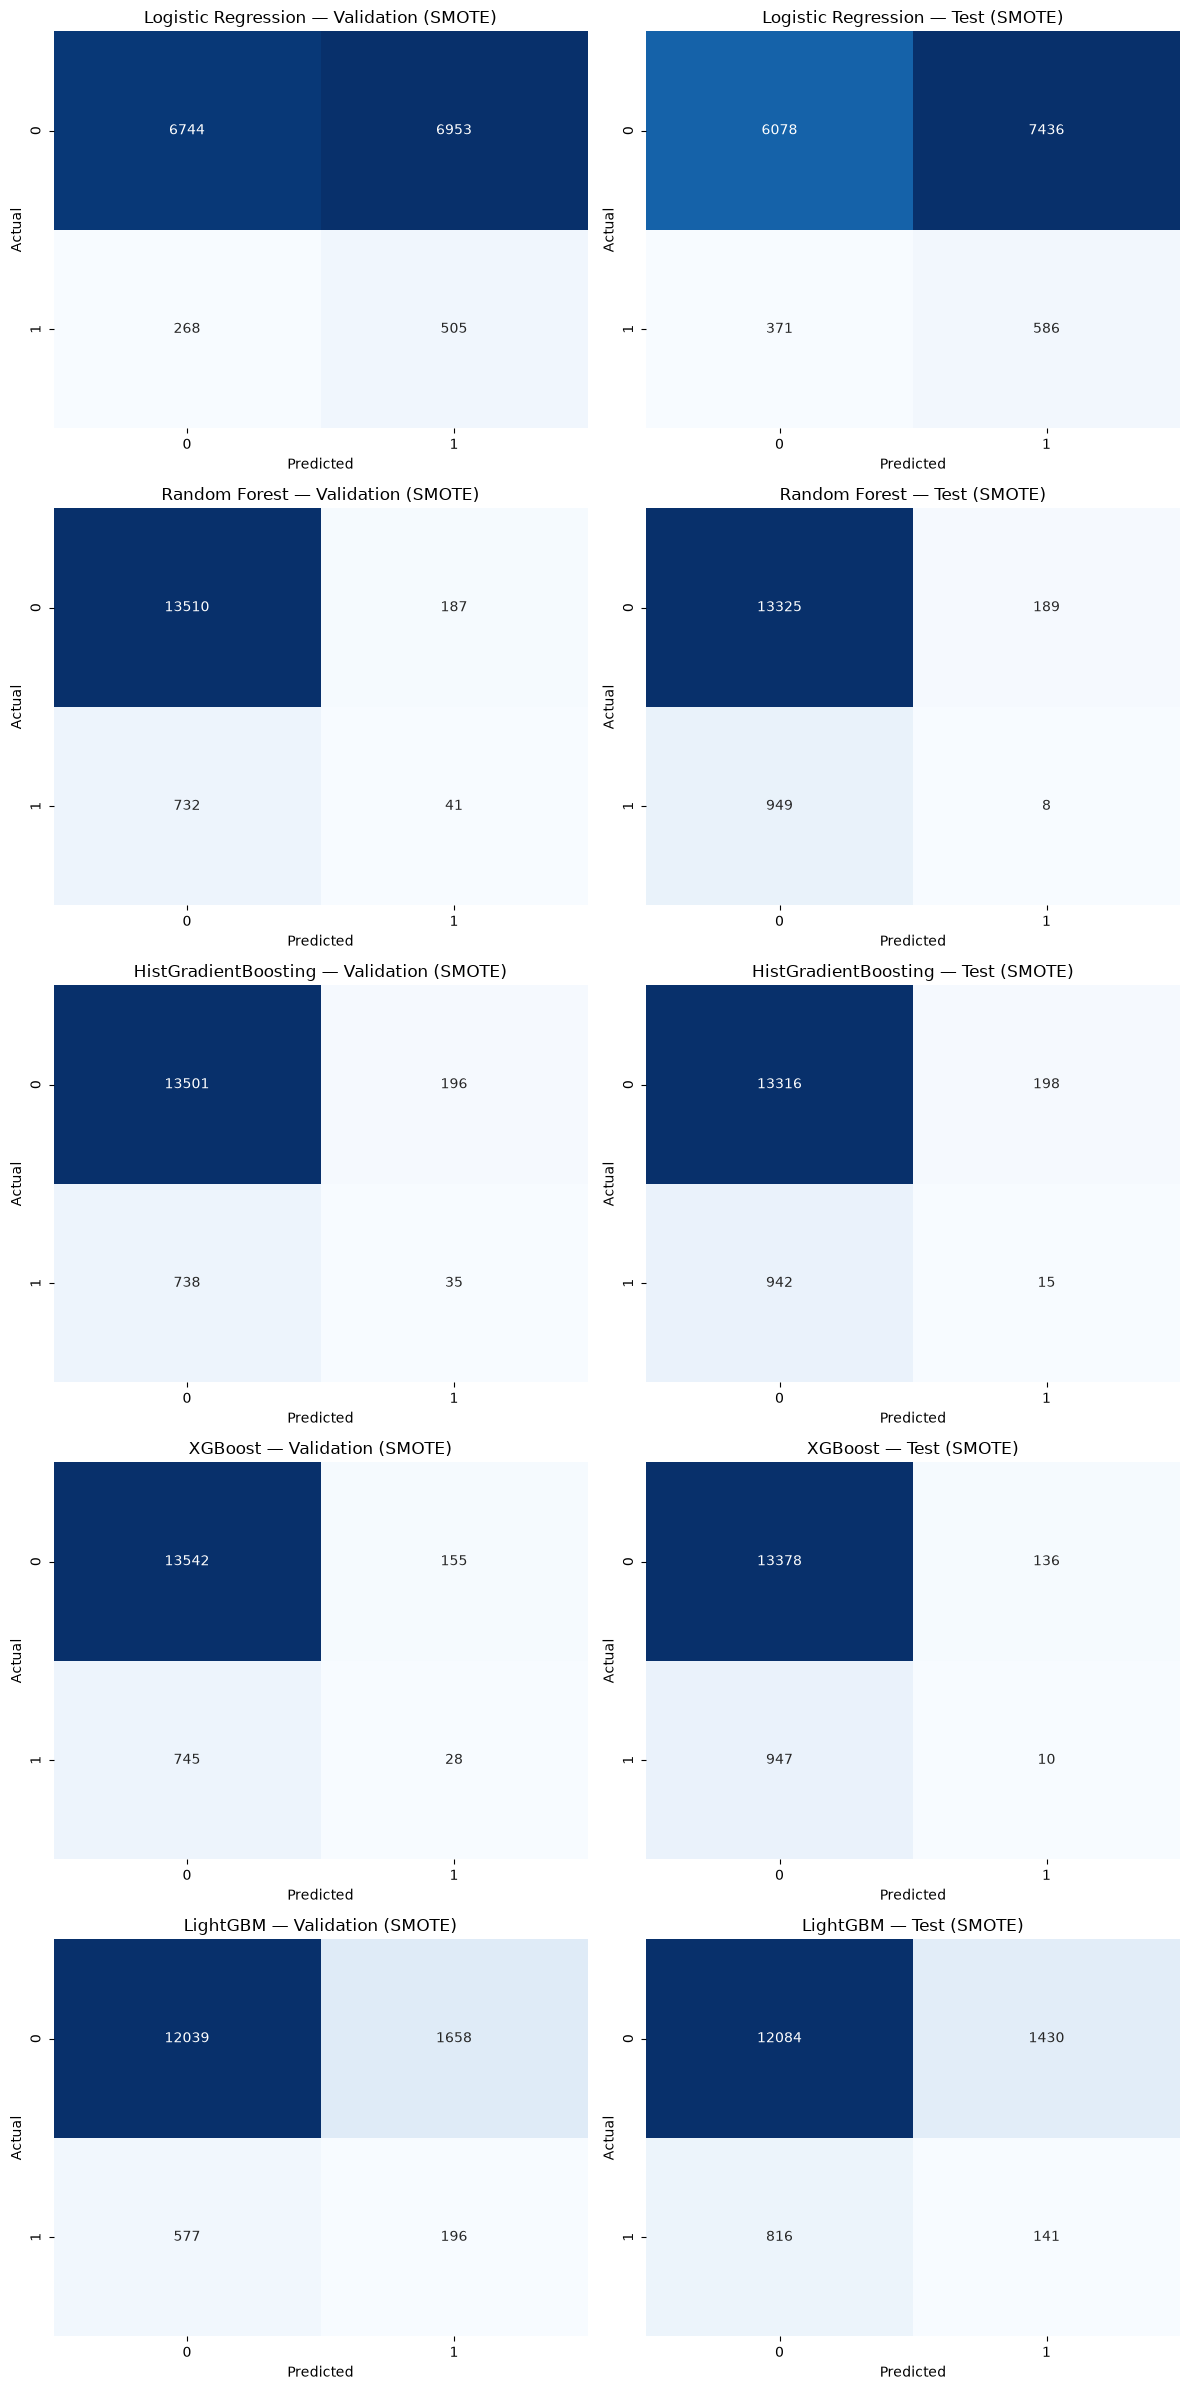

In [5]:
# ============================================================
# CONFUSION MATRICES — SMOTE
# ============================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(12, 24)
)

for row, (name, model) in enumerate(trained_models_smote.items()):

    val_pred = model.predict(X_validation_scaled)
    test_pred = model.predict(X_test_scaled)

    cm_val = confusion_matrix(y_validation, val_pred)
    cm_test = confusion_matrix(y_test, test_pred)

    # Validation
    sns.heatmap(
        cm_val,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[row, 0]
    )

    axes[row, 0].set_title(f"{name} — Validation (SMOTE)")
    axes[row, 0].set_xlabel("Predicted")
    axes[row, 0].set_ylabel("Actual")

    # Test
    sns.heatmap(
        cm_test,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[row, 1]
    )

    axes[row, 1].set_title(f"{name} — Test (SMOTE)")
    axes[row, 1].set_xlabel("Predicted")
    axes[row, 1].set_ylabel("Actual")


plt.tight_layout()
plt.show()

## Train 3 (Threshold)

In [6]:
# ============================================================
# BINARY CLASSIFICATION — 5 MODELS
# IMBALANCED DATA + CLASS WEIGHTING + THRESHOLD TUNING
# NO SMOTE / NO RESAMPLING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ============================================================
# 1. MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}


# ============================================================
# 2. TRAIN + THRESHOLD TUNING
# ============================================================

results = []
trained_models = {}
best_thresholds = {}

thresholds = np.arange(0.10, 0.71, 0.01)

for name, model in models.items():

    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    # --------------------------------------------------------
    # Train — ORIGINAL IMBALANCED DATA
    # --------------------------------------------------------

    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    # --------------------------------------------------------
    # Validation probabilities
    # --------------------------------------------------------

    val_prob = model.predict_proba(
        X_validation_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Find best threshold using Validation F1
    # --------------------------------------------------------

    threshold_results = []

    for threshold in thresholds:

        val_pred_temp = (
            val_prob >= threshold
        ).astype(int)

        f1 = f1_score(
            y_validation,
            val_pred_temp,
            zero_division=0
        )

        threshold_results.append({
            "threshold": threshold,
            "f1": f1
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_row = threshold_df.loc[
        threshold_df["f1"].idxmax()
    ]

    best_threshold = best_row["threshold"]

    best_thresholds[name] = best_threshold

    # --------------------------------------------------------
    # Validation predictions using BEST threshold
    # --------------------------------------------------------

    val_pred = (
        val_prob >= best_threshold
    ).astype(int)

    val_accuracy = accuracy_score(
        y_validation,
        val_pred
    )

    val_f1 = f1_score(
        y_validation,
        val_pred,
        zero_division=0
    )

    val_precision = precision_score(
        y_validation,
        val_pred,
        zero_division=0
    )

    val_recall = recall_score(
        y_validation,
        val_pred,
        zero_division=0
    )

    val_roc_auc = roc_auc_score(
        y_validation,
        val_prob
    )

    # --------------------------------------------------------
    # Test — SAME threshold
    # --------------------------------------------------------

    test_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    test_pred = (
        test_prob >= best_threshold
    ).astype(int)

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    test_f1 = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    test_precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    test_roc_auc = roc_auc_score(
        y_test,
        test_prob
    )

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results.append({
        "Model": name,
        "Best Threshold": best_threshold,

        "Validation Accuracy": val_accuracy,
        "Validation F1": val_f1,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation ROC-AUC": val_roc_auc,

        "Test Accuracy": test_accuracy,
        "Test F1": test_f1,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test ROC-AUC": test_roc_auc
    })

    print(
        f"Best Threshold: {best_threshold:.2f}"
    )

    print(
        f"Validation | "
        f"Accuracy: {val_accuracy:.4f} | "
        f"F1: {val_f1:.4f} | "
        f"Precision: {val_precision:.4f} | "
        f"Recall: {val_recall:.4f} | "
        f"ROC-AUC: {val_roc_auc:.4f}"
    )

    print(
        f"Test       | "
        f"Accuracy: {test_accuracy:.4f} | "
        f"F1: {test_f1:.4f} | "
        f"Precision: {test_precision:.4f} | "
        f"Recall: {test_recall:.4f} | "
        f"ROC-AUC: {test_roc_auc:.4f}"
    )


# ============================================================
# 3. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Validation F1",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 110)
print("MODEL COMPARISON — NO SMOTE + CLASS WEIGHTING + THRESHOLD TUNING")
print("=" * 110)

display(
    results_df.style.format({
        col: "{:.4f}"
        for col in results_df.columns
        if col != "Model"
    })
)

Training: Logistic Regression
Best Threshold: 0.70
Validation | Accuracy: 0.7554 | F1: 0.1441 | Precision: 0.0886 | Recall: 0.3855 | ROC-AUC: 0.6073
Test       | Accuracy: 0.7205 | F1: 0.1201 | Precision: 0.0758 | Recall: 0.2884 | ROC-AUC: 0.5418
Training: Random Forest
Best Threshold: 0.21
Validation | Accuracy: 0.8140 | F1: 0.1768 | Precision: 0.1158 | Recall: 0.3739 | ROC-AUC: 0.6419
Test       | Accuracy: 0.8100 | F1: 0.1141 | Precision: 0.0825 | Recall: 0.1850 | ROC-AUC: 0.5390
Training: HistGradientBoosting
Best Threshold: 0.10
Validation | Accuracy: 0.7933 | F1: 0.1620 | Precision: 0.1034 | Recall: 0.3739 | ROC-AUC: 0.6317
Test       | Accuracy: 0.7912 | F1: 0.1133 | Precision: 0.0788 | Recall: 0.2017 | ROC-AUC: 0.5274
Training: XGBoost
Best Threshold: 0.11
Validation | Accuracy: 0.8279 | F1: 0.1570 | Precision: 0.1063 | Recall: 0.3001 | ROC-AUC: 0.6392
Test       | Accuracy: 0.8324 | F1: 0.1198 | Precision: 0.0918 | Recall: 0.1724 | ROC-AUC: 0.5202
Training: LightGBM
Best Thres

,Model,Best Threshold,Validation Accuracy,Validation F1,Validation Precision,Validation Recall,Validation ROC-AUC,Test Accuracy,Test F1,Test Precision,Test Recall,Test ROC-AUC
0,Random Forest,0.2100,0.8140,0.1768,0.1158,0.3739,0.6419,0.8100,0.1141,0.0825,0.1850,0.5390
1,HistGradientBoosting,0.1000,0.7933,0.1620,0.1034,0.3739,0.6317,0.7912,0.1133,0.0788,0.2017,0.5274
2,LightGBM,0.4600,0.7989,0.1614,0.1038,0.3622,0.6410,0.8004,0.1162,0.0822,0.1985,0.5346
3,XGBoost,0.1100,0.8279,0.1570,0.1063,0.3001,0.6392,0.8324,0.1198,0.0918,0.1724,0.5202
4,Logistic Regression,0.7000,0.7554,0.1441,0.0886,0.3855,0.6073,0.7205,0.1201,0.0758,0.2884,0.5418


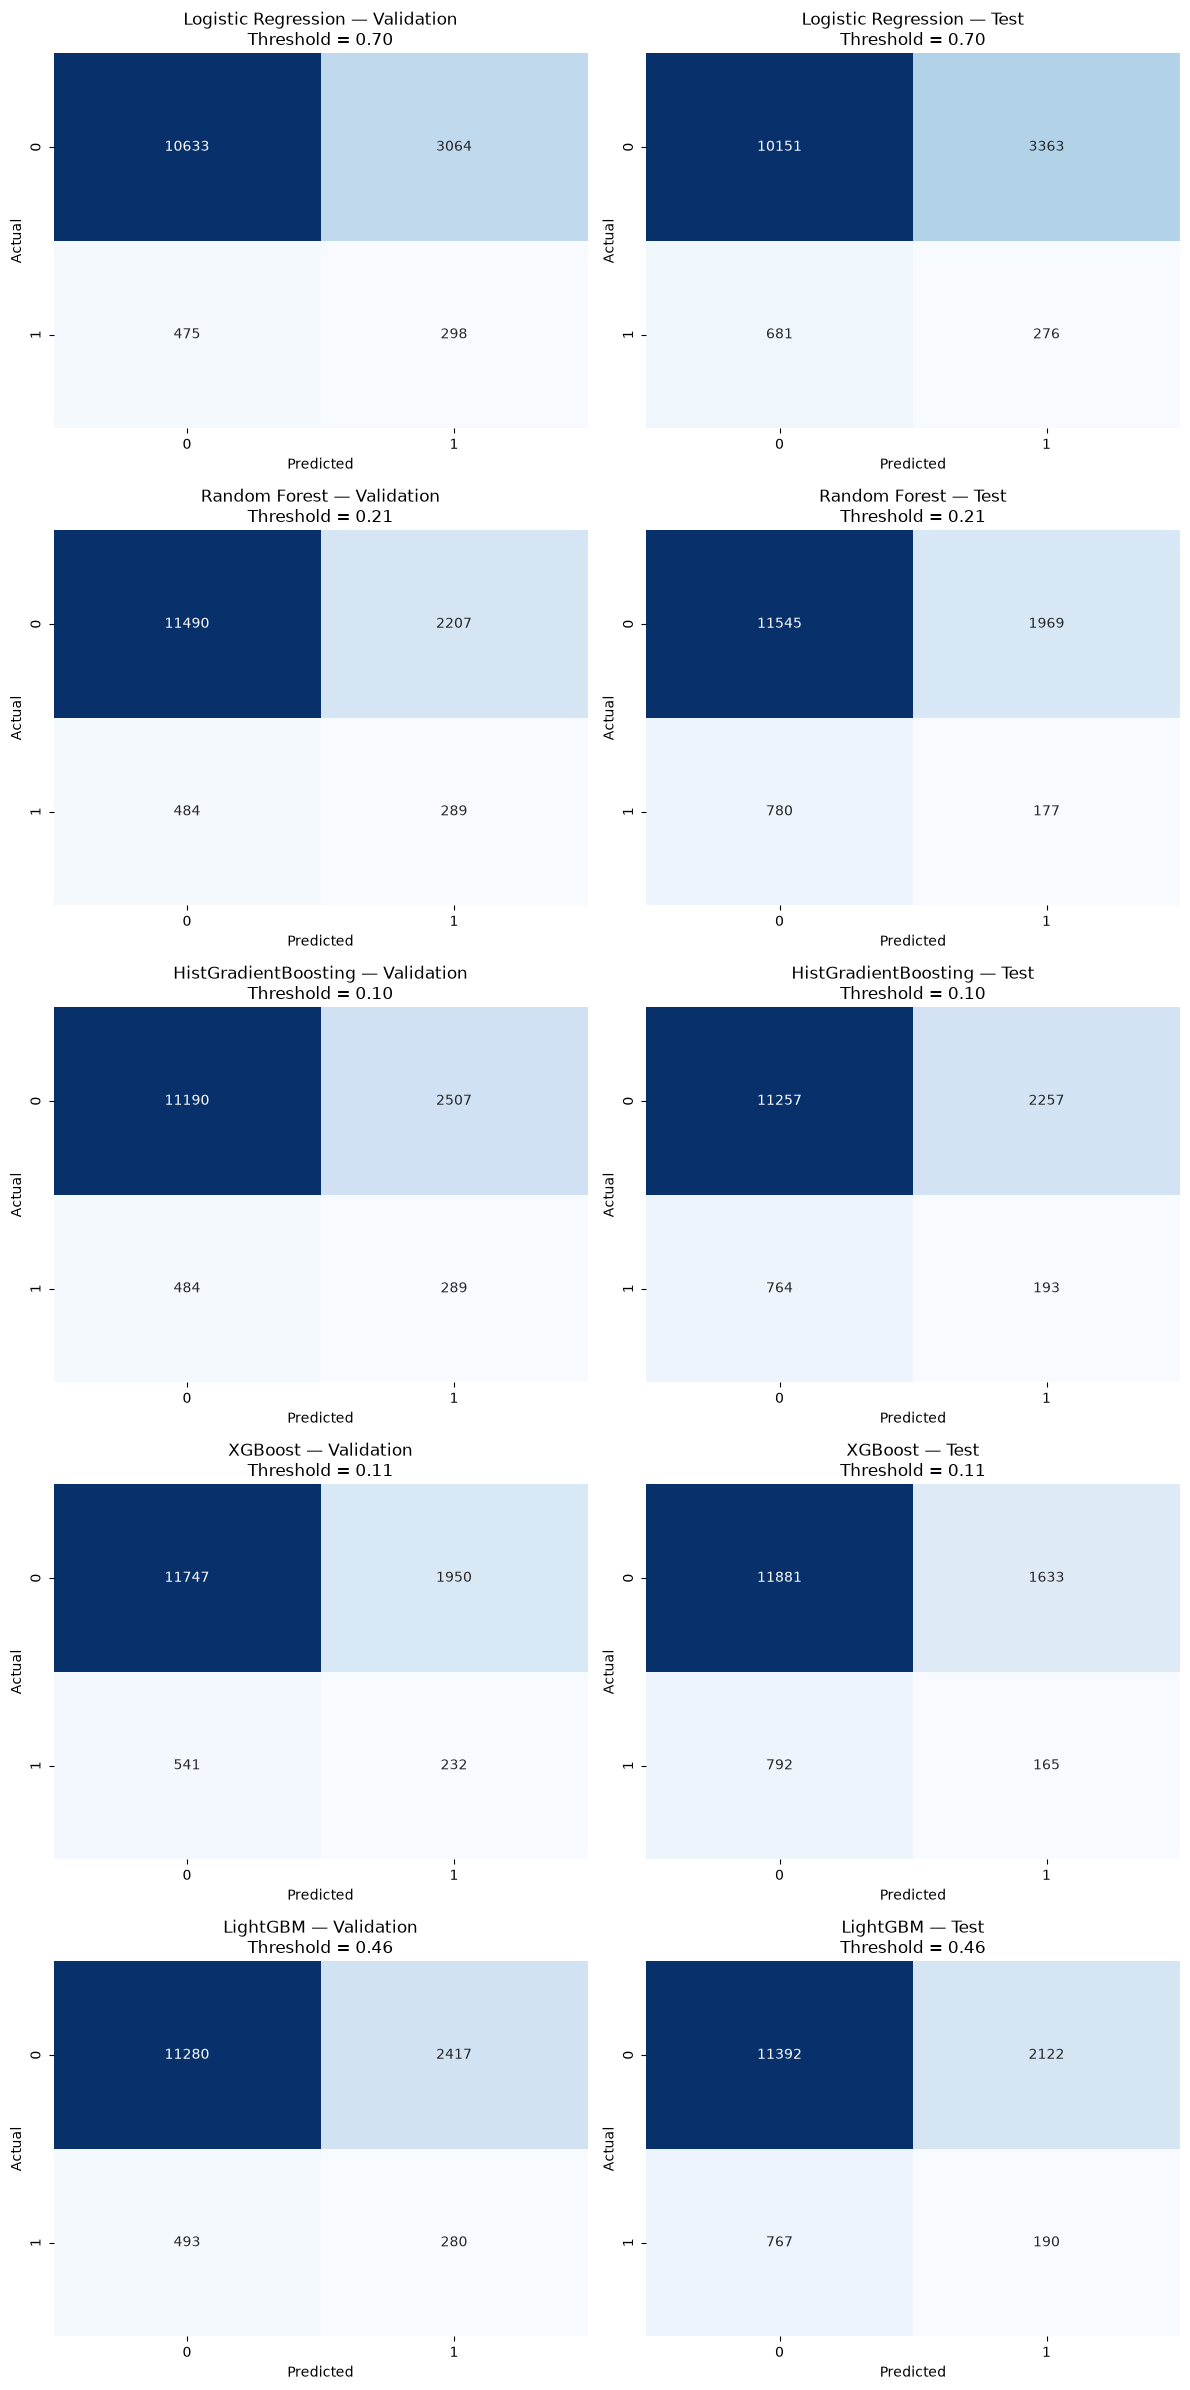

In [7]:
# ============================================================
# CONFUSION MATRICES — THRESHOLD TUNING
# ============================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(12, 24)
)

for row, (name, model) in enumerate(trained_models.items()):

    threshold = best_thresholds[name]

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_prob = model.predict_proba(
        X_validation_scaled
    )[:, 1]

    val_pred = (
        val_prob >= threshold
    ).astype(int)

    cm_val = confusion_matrix(
        y_validation,
        val_pred
    )

    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    test_pred = (
        test_prob >= threshold
    ).astype(int)

    cm_test = confusion_matrix(
        y_test,
        test_pred
    )

    # --------------------------------------------------------
    # Validation Matrix
    # --------------------------------------------------------

    sns.heatmap(
        cm_val,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[row, 0]
    )

    axes[row, 0].set_title(
        f"{name} — Validation\nThreshold = {threshold:.2f}"
    )

    axes[row, 0].set_xlabel("Predicted")
    axes[row, 0].set_ylabel("Actual")

    # --------------------------------------------------------
    # Test Matrix
    # --------------------------------------------------------

    sns.heatmap(
        cm_test,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[row, 1]
    )

    axes[row, 1].set_title(
        f"{name} — Test\nThreshold = {threshold:.2f}"
    )

    axes[row, 1].set_xlabel("Predicted")
    axes[row, 1].set_ylabel("Actual")


plt.tight_layout()
plt.show()

# Extra: Delay Days (Regression)

In [8]:
# ============================================================
# REGRESSION — DELAY DAYS
# 2 MODELS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# ============================================================
# 1. MODELS
# ============================================================

models_reg = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1
    )
}


# ============================================================
# 2. TRAIN + VALIDATION + TEST
# ============================================================

results_regression = []
trained_models_regression = {}

for name, model in models_reg.items():

    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_reg_scaled,
        y_train_reg
    )

    trained_models_regression[name] = model

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_pred = model.predict(X_validation_reg_scaled)

    val_mae = mean_absolute_error(
        y_validation_reg,
        val_pred
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            y_validation_reg,
            val_pred
        )
    )

    val_r2 = r2_score(
        y_validation_reg,
        val_pred
    )

    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_pred = model.predict(X_test_reg_scaled)

    test_mae = mean_absolute_error(
        y_test_reg,
        test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            test_pred
        )
    )

    test_r2 = r2_score(
        y_test_reg,
        test_pred
    )

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results_regression.append({

        "Model": name,

        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Validation R2": val_r2,

        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R2": test_r2
    })

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(
        f"Validation | "
        f"MAE: {val_mae:.4f} | "
        f"RMSE: {val_rmse:.4f} | "
        f"R²: {val_r2:.4f}"
    )

    print(
        f"Test       | "
        f"MAE: {test_mae:.4f} | "
        f"RMSE: {test_rmse:.4f} | "
        f"R²: {test_r2:.4f}"
    )


# ============================================================
# 3. RESULTS TABLE
# ============================================================

results_regression_df = pd.DataFrame(
    results_regression
)

# Sort by Validation RMSE
results_regression_df = (
    results_regression_df
    .sort_values(
        by="Validation RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("REGRESSION MODEL COMPARISON — DELAY DAYS")
print("=" * 100)

display(
    results_regression_df.style.format({
        col: "{:.4f}"
        for col in results_regression_df.columns
        if col != "Model"
    })
)

Training: Random Forest
Validation | MAE: 7.9839 | RMSE: 10.8721 | R²: -0.2202
Test       | MAE: 7.2406 | RMSE: 9.4466 | R²: -0.2820
Training: XGBoost
Validation | MAE: 7.7921 | RMSE: 10.5175 | R²: -0.1419
Test       | MAE: 6.7061 | RMSE: 8.7816 | R²: -0.1078

REGRESSION MODEL COMPARISON — DELAY DAYS


,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,XGBoost,7.7921,10.5175,-0.1419,6.7061,8.7816,-0.1078
1,Random Forest,7.9839,10.8721,-0.2202,7.2406,9.4466,-0.2820


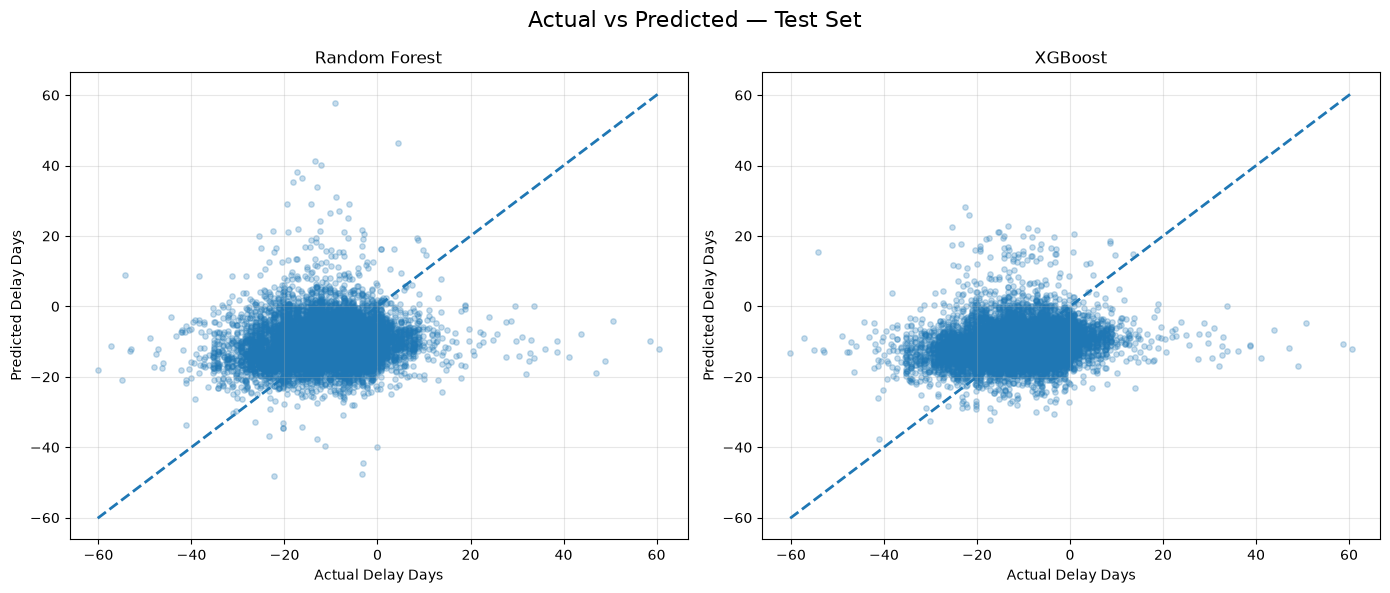

In [9]:
# ============================================================
# REGRESSION PLOTS — ACTUAL VS PREDICTED
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    1,
    len(trained_models_regression),
    figsize=(14, 6)
)

if len(trained_models_regression) == 1:
    axes = [axes]

for ax, (name, model) in zip(
    axes,
    trained_models_regression.items()
):

    # Test predictions
    test_pred = model.predict(X_test_reg_scaled)

    # Actual vs Predicted
    ax.scatter(
        y_test_reg,
        test_pred,
        alpha=0.25,
        s=15
    )

    # Perfect prediction line
    min_value = min(
        y_test_reg.min(),
        test_pred.min()
    )

    max_value = max(
        y_test_reg.max(),
        test_pred.max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel("Actual Delay Days")
    ax.set_ylabel("Predicted Delay Days")
    ax.grid(alpha=0.3)

plt.suptitle(
    "Actual vs Predicted — Test Set",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# REGRESSION EXPERIMENT 1
# REMOVE NEGATIVE delay_days
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# ============================================================
# 1. FILTER TARGET
# ============================================================

train_mask = y_train_reg >= 0
validation_mask = y_validation_reg >= 0
test_mask = y_test_reg >= 0

X_train_reg_exp1 = X_train_reg_scaled[train_mask]
y_train_reg_exp1 = y_train_reg[train_mask]

X_validation_reg_exp1 = X_validation_reg_scaled[validation_mask]
y_validation_reg_exp1 = y_validation_reg[validation_mask]

X_test_reg_exp1 = X_test_reg_scaled[test_mask]
y_test_reg_exp1 = y_test_reg[test_mask]

print("Rows after removing negative delay_days:")
print(f"Train      : {len(y_train_reg_exp1):,}")
print(f"Validation : {len(y_validation_reg_exp1):,}")
print(f"Test       : {len(y_test_reg_exp1):,}")


# ============================================================
# 2. MODELS
# ============================================================

models_reg_exp1 = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1
    )
}


# ============================================================
# 3. TRAIN + VALIDATION + TEST
# ============================================================

results_regression_exp1 = []
trained_models_regression_exp1 = {}

for name, model in models_reg_exp1.items():

    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    model.fit(
        X_train_reg_exp1,
        y_train_reg_exp1
    )

    trained_models_regression_exp1[name] = model

    # Validation
    val_pred = model.predict(X_validation_reg_exp1)

    val_mae = mean_absolute_error(
        y_validation_reg_exp1,
        val_pred
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            y_validation_reg_exp1,
            val_pred
        )
    )

    val_r2 = r2_score(
        y_validation_reg_exp1,
        val_pred
    )

    # Test
    test_pred = model.predict(X_test_reg_exp1)

    test_mae = mean_absolute_error(
        y_test_reg_exp1,
        test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test_reg_exp1,
            test_pred
        )
    )

    test_r2 = r2_score(
        y_test_reg_exp1,
        test_pred
    )

    results_regression_exp1.append({
        "Model": name,

        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Validation R2": val_r2,

        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R2": test_r2
    })

    print(
        f"Validation | "
        f"MAE: {val_mae:.4f} | "
        f"RMSE: {val_rmse:.4f} | "
        f"R²: {val_r2:.4f}"
    )

    print(
        f"Test       | "
        f"MAE: {test_mae:.4f} | "
        f"RMSE: {test_rmse:.4f} | "
        f"R²: {test_r2:.4f}"
    )


# ============================================================
# 4. RESULTS
# ============================================================

results_regression_exp1_df = (
    pd.DataFrame(results_regression_exp1)
    .sort_values(
        by="Validation RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    results_regression_exp1_df.style.format({
        col: "{:.4f}"
        for col in results_regression_exp1_df.columns
        if col != "Model"
    })
)

Rows after removing negative delay_days:
Train      : 6,096
Validation : 773
Test       : 957
Training: Random Forest
Validation | MAE: 5.9348 | RMSE: 8.9869 | R²: -0.1274
Test       | MAE: 5.9482 | RMSE: 8.6450 | R²: -0.6269
Training: XGBoost
Validation | MAE: 5.7340 | RMSE: 8.9567 | R²: -0.1198
Test       | MAE: 5.3796 | RMSE: 8.0320 | R²: -0.4043


,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,XGBoost,5.7340,8.9567,-0.1198,5.3796,8.0320,-0.4043
1,Random Forest,5.9348,8.9869,-0.1274,5.9482,8.6450,-0.6269


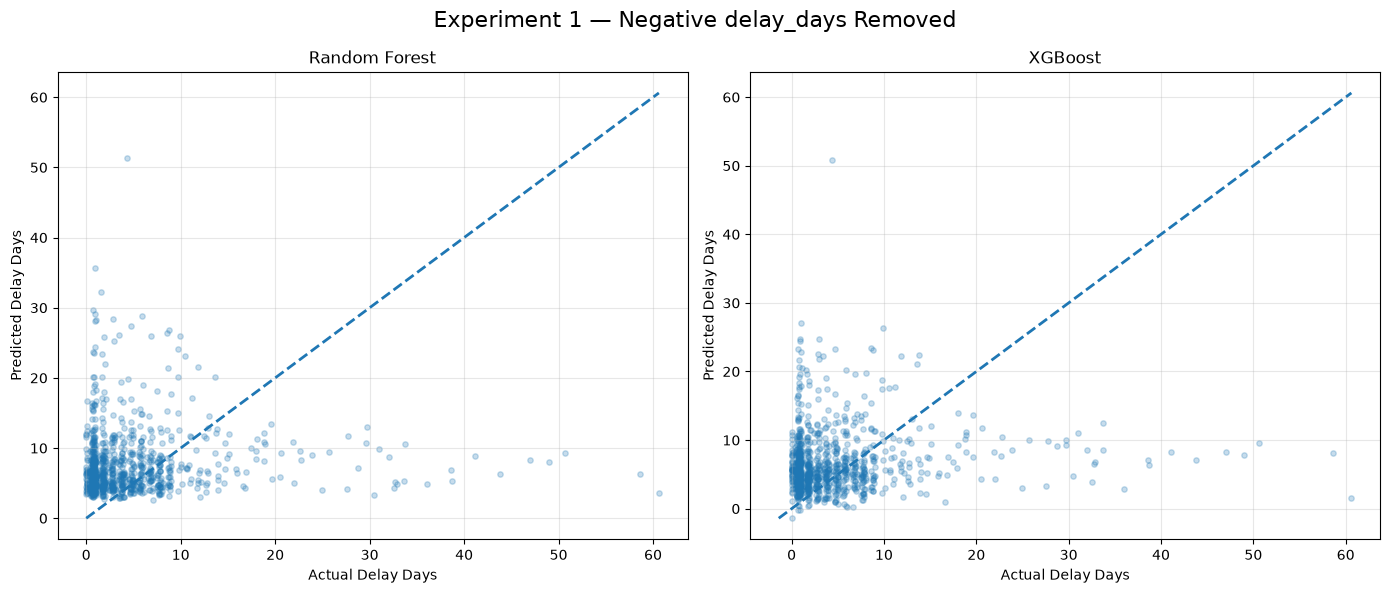

In [11]:
# ============================================================
# PLOT — EXPERIMENT 1
# REMOVE NEGATIVE delay_days
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

for ax, (name, model) in zip(
    axes,
    trained_models_regression_exp1.items()
):

    test_pred = model.predict(X_test_reg_exp1)

    ax.scatter(
        y_test_reg_exp1,
        test_pred,
        alpha=0.25,
        s=15
    )

    min_value = min(
        y_test_reg_exp1.min(),
        test_pred.min()
    )

    max_value = max(
        y_test_reg_exp1.max(),
        test_pred.max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel("Actual Delay Days")
    ax.set_ylabel("Predicted Delay Days")
    ax.grid(alpha=0.3)

plt.suptitle(
    "Experiment 1 — Negative delay_days Removed",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# REGRESSION EXPERIMENT 2
# CONVERT NEGATIVE delay_days TO ZERO
# ============================================================

# ============================================================
# 1. TRANSFORM TARGET
# ============================================================

y_train_reg_exp2 = y_train_reg.clip(lower=0)
y_validation_reg_exp2 = y_validation_reg.clip(lower=0)
y_test_reg_exp2 = y_test_reg.clip(lower=0)

print("Negative values converted to zero:")
print(f"Train      : {(y_train_reg < 0).sum():,} → 0")
print(f"Validation : {(y_validation_reg < 0).sum():,} → 0")
print(f"Test       : {(y_test_reg < 0).sum():,} → 0")


# ============================================================
# 2. MODELS
# ============================================================

models_reg_exp2 = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1
    )
}


# ============================================================
# 3. TRAIN + VALIDATION + TEST
# ============================================================

results_regression_exp2 = []
trained_models_regression_exp2 = {}

for name, model in models_reg_exp2.items():

    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    model.fit(
        X_train_reg_scaled,
        y_train_reg_exp2
    )

    trained_models_regression_exp2[name] = model

    # Validation
    val_pred = model.predict(X_validation_reg_scaled)

    val_mae = mean_absolute_error(
        y_validation_reg_exp2,
        val_pred
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            y_validation_reg_exp2,
            val_pred
        )
    )

    val_r2 = r2_score(
        y_validation_reg_exp2,
        val_pred
    )

    # Test
    test_pred = model.predict(X_test_reg_scaled)

    test_mae = mean_absolute_error(
        y_test_reg_exp2,
        test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test_reg_exp2,
            test_pred
        )
    )

    test_r2 = r2_score(
        y_test_reg_exp2,
        test_pred
    )

    results_regression_exp2.append({
        "Model": name,

        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Validation R2": val_r2,

        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R2": test_r2
    })

    print(
        f"Validation | "
        f"MAE: {val_mae:.4f} | "
        f"RMSE: {val_rmse:.4f} | "
        f"R²: {val_r2:.4f}"
    )

    print(
        f"Test       | "
        f"MAE: {test_mae:.4f} | "
        f"RMSE: {test_rmse:.4f} | "
        f"R²: {test_r2:.4f}"
    )


# ============================================================
# 4. RESULTS
# ============================================================

results_regression_exp2_df = (
    pd.DataFrame(results_regression_exp2)
    .sort_values(
        by="Validation RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    results_regression_exp2_df.style.format({
        col: "{:.4f}"
        for col in results_regression_exp2_df.columns
        if col != "Model"
    })
)

Negative values converted to zero:
Train      : 61,431 → 0
Validation : 13,697 → 0
Test       : 13,514 → 0
Training: Random Forest
Validation | MAE: 1.4356 | RMSE: 3.4202 | R²: -0.8389
Test       | MAE: 1.3461 | RMSE: 3.2171 | R²: -1.3856
Training: XGBoost
Validation | MAE: 1.1366 | RMSE: 3.1150 | R²: -0.5253
Test       | MAE: 1.0514 | RMSE: 2.7882 | R²: -0.7919


,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,XGBoost,1.1366,3.1150,-0.5253,1.0514,2.7882,-0.7919
1,Random Forest,1.4356,3.4202,-0.8389,1.3461,3.2171,-1.3856


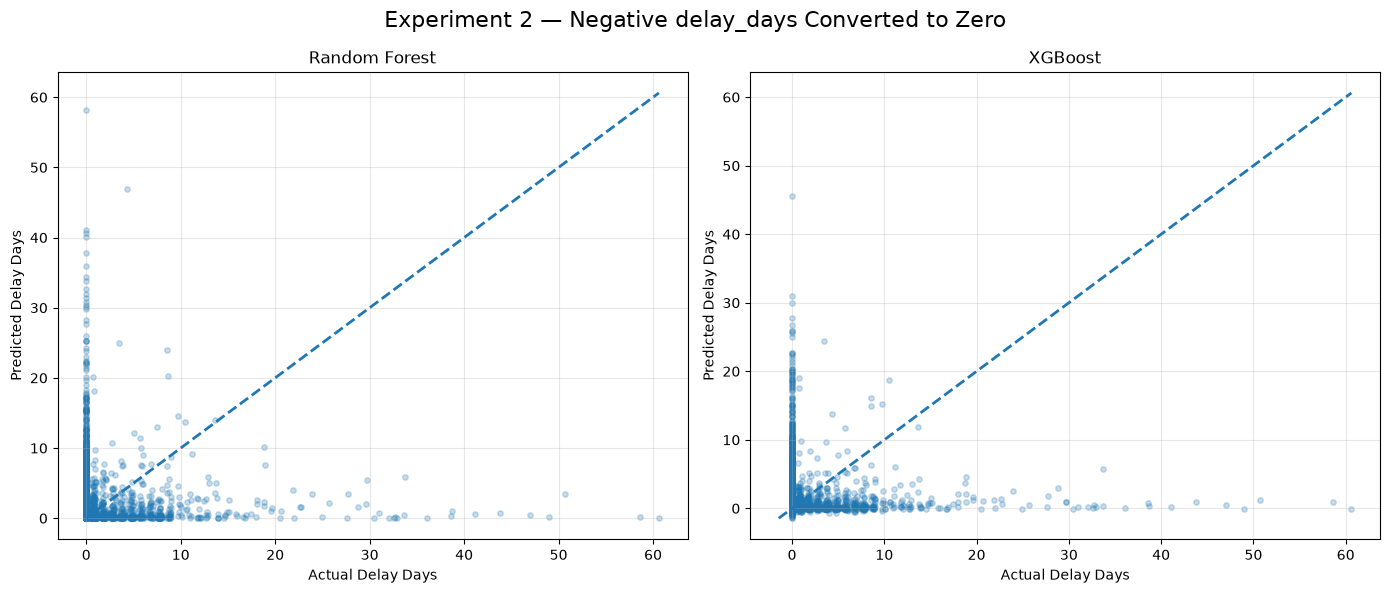

In [13]:
# ============================================================
# PLOT — EXPERIMENT 2
# NEGATIVE delay_days → 0
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

for ax, (name, model) in zip(
    axes,
    trained_models_regression_exp2.items()
):

    test_pred = model.predict(X_test_reg_scaled)

    ax.scatter(
        y_test_reg_exp2,
        test_pred,
        alpha=0.25,
        s=15
    )

    min_value = min(
        y_test_reg_exp2.min(),
        test_pred.min()
    )

    max_value = max(
        y_test_reg_exp2.max(),
        test_pred.max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel("Actual Delay Days")
    ax.set_ylabel("Predicted Delay Days")
    ax.grid(alpha=0.3)

plt.suptitle(
    "Experiment 2 — Negative delay_days Converted to Zero",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Save

In [14]:
from pathlib import Path
import joblib

# ============================================================
# SAVE SMOTE LOGISTIC REGRESSION MODEL
# ============================================================

MODEL_DIR = Path("../artifacts/models/classification")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

logistic_regression_smote = trained_models_smote["Logistic Regression"]

joblib.dump(
    logistic_regression_smote,
    MODEL_DIR / "logistic_regression_smote.joblib"
)

print("=" * 70)
print("SMOTE Logistic Regression model saved successfully.")
print("=" * 70)
print(MODEL_DIR / "logistic_regression_smote.joblib")

SMOTE Logistic Regression model saved successfully.
../artifacts/models/classification/logistic_regression_smote.joblib


In [15]:
from pathlib import Path
import joblib

# ============================================================
# SAVE REGRESSION MODELS — EXPERIMENT 1
# ============================================================

MODEL_DIR = Path("../artifacts/models/regression")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for name, model in trained_models_regression_exp1.items():
    filename = name.lower().replace(" ", "_") + "_exp1.joblib"
    joblib.dump(model, MODEL_DIR / filename)

print("=" * 70)
print("REGRESSION MODELS — EXPERIMENT 1 SAVED")
print("=" * 70)

for path in sorted(MODEL_DIR.glob("*_exp1.joblib")):
    print(path.name)

REGRESSION MODELS — EXPERIMENT 1 SAVED
random_forest_exp1.joblib
xgboost_exp1.joblib
